# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Step 1: Load the dataset
data = pd.read_csv('/Users/paolarivera/Documents/Ironhack/Week 5/Day 3/lab-neural-networks-master/your-code/tic-tac-toe.csv')

# Step 2: Inspect the dataset
print(data.head())
print(data.info())

# Step 3: Convert categorical values to numeric
label_encoder = LabelEncoder()
data = data.apply(label_encoder.fit_transform)

# Step 4: Separate inputs and output
X = data.drop('class', axis=1)
y = data['class']

# Step 5: Normalize the input data
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print("Data engineering completed.")

  TL TM TR ML MM MR BL BM BR  class
0  x  x  x  x  o  o  x  o  o   True
1  x  x  x  x  o  o  o  x  o   True
2  x  x  x  x  o  o  o  o  x   True
3  x  x  x  x  o  o  o  b  b   True
4  x  x  x  x  o  o  b  o  b   True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   TL      958 non-null    object
 1   TM      958 non-null    object
 2   TR      958 non-null    object
 3   ML      958 non-null    object
 4   MM      958 non-null    object
 5   MR      958 non-null    object
 6   BL      958 non-null    object
 7   BM      958 non-null    object
 8   BR      958 non-null    object
 9   class   958 non-null    bool  
dtypes: bool(1), object(9)
memory usage: 68.4+ KB
None
Data engineering completed.


## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Step 1: Split the training and test data
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Step 2: Create a Sequential model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')  # Assuming binary classification with two classes
])

# Step 3: Compile the model
model.compile(optimizer=Adam(), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Step 4: Fit the training data
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

# Step 5: Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Step 6: Save the model with the .keras extension
model.save('tic-tac-toe.keras')

print("Model training and saving completed.")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4557 - loss: 0.7290 - val_accuracy: 0.6818 - val_loss: 0.6222
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6454 - val_accuracy: 0.6818 - val_loss: 0.6201
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6682 - loss: 0.6093 - val_accuracy: 0.6883 - val_loss: 0.6207
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6692 - loss: 0.5976 - val_accuracy: 0.6883 - val_loss: 0.6181
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6846 - loss: 0.6054 - val_accuracy: 0.6753 - val_loss: 0.6141
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6751 - loss: 0.5905 - val_accuracy: 0.6948 - val_loss: 0.6136
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6897 - loss: 0.5772 - val_accuracy: 0.6883 - val_loss: 0.6148
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7038 - loss: 0.5877 - val_accuracy: 0.6948 - val_loss:

## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [5]:
import numpy as np
import tensorflow as tf

# Step 1: Load the saved model
loaded_model = tf.keras.models.load_model('tic-tac-toe.keras')

# Step 2: Make predictions on a few random rows
random_indices = np.random.choice(X_test.shape[0], size=5, replace=False)
sample_data = X_test[random_indices]
sample_labels = y_test.iloc[random_indices]

predictions = loaded_model.predict(sample_data)
predicted_classes = np.argmax(predictions, axis=1)

# Step 3: Compare predictions with actual labels
for i, index in enumerate(random_indices):
    print(f"Sample {i+1}:")
    print(f"Actual Label: {sample_labels.iloc[i]}, Predicted Label: {predicted_classes[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Sample 1:
Actual Label: 1, Predicted Label: 1
Sample 2:
Actual Label: 1, Predicted Label: 1
Sample 3:
Actual Label: 0, Predicted Label: 1
Sample 4:
Actual Label: 1, Predicted Label: 1
Sample 5:
Actual Label: 0, Predicted Label: 0


## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [7]:
from tensorflow.keras.optimizers import Adam

# Step 1: Modify the model with additional layers
improved_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')  # Assuming binary classification
])

# Step 2: Adjust the learning rate
custom_optimizer = Adam(learning_rate=0.001)

# Step 3: Compile the improved model
improved_model.compile(optimizer=custom_optimizer, 
                       loss='sparse_categorical_crossentropy', 
                       metrics=['accuracy'])

# Step 4: Fit the training data with more epochs
improved_model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2)

# Step 5: Evaluate the improved model
test_loss, test_accuracy = improved_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Step 6: Save the improved model
improved_model.save('tic-tac-toe-improved.keras')

print("Improved model training and saving completed.")

Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4924 - loss: 0.6990 - val_accuracy: 0.6818 - val_loss: 0.6490
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6490 - loss: 0.6493 - val_accuracy: 0.6818 - val_loss: 0.6202
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6485 - loss: 0.6301 - val_accuracy: 0.6818 - val_loss: 0.6183
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6622 - loss: 0.6052 - val_accuracy: 0.6883 - val_loss: 0.6164
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6659 - loss: 0.6100 - val_accuracy: 0.6883 - val_loss: 0.6184
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6937 - loss: 0.5862 - val_accuracy: 0.6753 - val_loss: 0.6224
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7399 - loss: 0.5539 - val_accuracy: 0.6818 - val_loss: 0.6172
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7470 - loss: 0.5562 - val_accuracy: 0.7078 - val_loss: 0.5

**Which approach(es) did you find helpful to improve your model performance?**

Applying aditional layers improved the model's capacity by a ton. Also using the Adam Optimizer helped better adapt our model and increased accuracy! :)

# Challenge 2 - Tensorflow Playground Screenshot

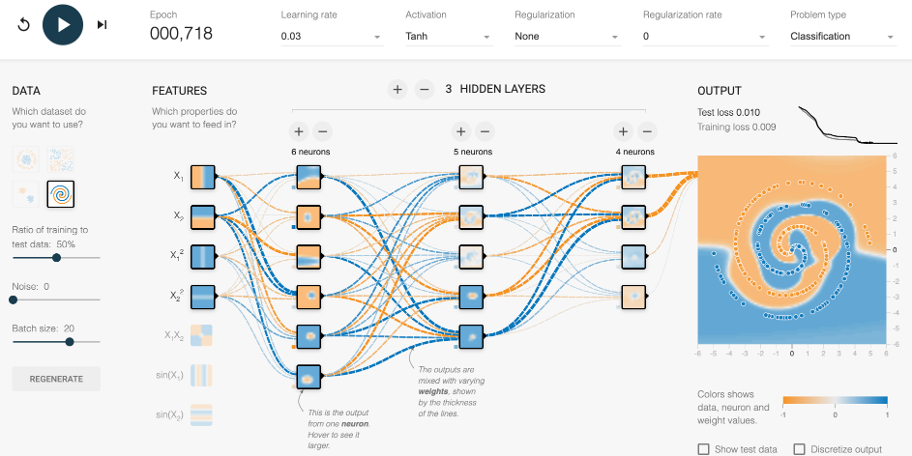